# Prédiction du prix d'une voiture d'occasion





In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm streamlit joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Chargement et découverte des données

>Les données fournis par Kaggle (lien sur PDF de l'énoncé), C'est un fichier CSV nommé autos de 351 528 annonces de vehicules d'occasions en allemagne , avec 21 colonnes dont la variable cible est : "price"
PS: le dataset différe de la description sur l'énoncé mais peut etre utiliser pour le meme objectif : prédiction de prix 

In [ ]:
# loader le dataframe du fichier csv
df = pd.read_csv("data/autos.csv")

In [7]:
df.head()

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [8]:
df.shape

(371528, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand                371528 non-nu

In [10]:
df.describe()

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,nrOfPictures,postalCode
count,371528.000000,3.715280e+05,371528.000000,371528.000000,371528.000000,371528.000000,371528.0,371528.00000
mean,185763.500000,1.729514e+04,2004.577997,115.549477,125618.688228,5.734445,0.0,50820.66764
std,107251.039743,3.587954e+06,92.866598,192.139578,40112.337051,3.712412,0.0,25799.08247
min,0.000000,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.00000
25%,92881.750000,1.150000e+03,1999.000000,70.000000,125000.000000,3.000000,0.0,30459.00000
50%,185763.500000,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,0.0,49610.00000
75%,278645.250000,7.200000e+03,2008.000000,150.000000,150000.000000,9.000000,0.0,71546.00000
max,371527.000000,2.147484e+09,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.00000


In [55]:
# identifier les modeles brands ...
df['brand'].nunique()


40

In [12]:
df['model'].nunique()

251

In [13]:
df['seller'].value_counts()

seller
privat        371525
gewerblich         3
Name: count, dtype: int64

In [14]:
df['offerType'].value_counts()

offerType
Angebot    371516
Gesuch         12
Name: count, dtype: int64

In [15]:
df['nrOfPictures'].value_counts()

nrOfPictures
0    371528
Name: count, dtype: int64

## 2. Nettoyage des colonnes

>Avant de travailler , on clean le dataset. Supprimer le nbrofpics car toujours constante (deja verifier) , on efface seller et offertype (presque constante), et enfin on retire les colonnes inutiles pour prédir le prix (dateofscrapping, index,codepostal,...)

In [ ]:
# creer une copie de dataframe pour etre plus secure
data = df.copy()

In [17]:
colonnes_a_supprimer = ['index', 'dateCrawled', 'seller', 'offerType',
                           'abtest', 'monthOfRegistration', 'nrOfPictures',
                           'postalCode', 'dateCreated', 'lastSeen']
data = data.drop(columns=colonnes_a_supprimer)

In [ ]:
# verifier apres la supression
data.head()

,name,price,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage
0,Golf_3_1.6,480,NaN,1993,manuell,0,golf,150000,benzin,volkswagen,NaN
1,A5_Sportback_2.7_Tdi,18300,coupe,2011,manuell,190,NaN,125000,diesel,audi,ja
2,"Jeep_Grand_Cherokee_""Overland""",9800,suv,2004,automatik,163,grand,125000,diesel,jeep,NaN
3,GOLF_4_1_4__3TÜRER,1500,kleinwagen,2001,manuell,75,golf,150000,benzin,volkswagen,nein
4,Skoda_Fabia_1.4_TDI_PD_Classic,3600,kleinwagen,2008,manuell,69,fabia,90000,diesel,skoda,nein


In [19]:
data.shape

(371528, 11)

## 3. Traitement des valeurs aberrantes
Apres analyse de df.describe() on peut reperer des valeurs aberrantes qu'on doit traiter avant la modelisation , comme exemples : des prix de 0 a 2milliards de euros des puissances de 0 à 2000ch , des années d'immatriculation de 1000 à 9999.
Ce que je compte faire c'est compter combien de lignes montrent chaque anomalie ,filtrer pour garder que des valeurs réalistes. et pour les valeurs nombreuses les transformer pour les imputer.

In [20]:
print("Prix = 0 :", (data['price'] == 0).sum())
print("Prix < 100 :", (data['price'] < 100).sum())
print("Prix > 150000 :", (data['price'] > 150000).sum())
print("Année < 1950 :", (data['yearOfRegistration'] < 1950).sum())
print("Année > 2016 :", (data['yearOfRegistration'] > 2016).sum())
print("PowerPS = 0 :", (data['powerPS'] == 0).sum())
print("PowerPS > 1000 :", (data['powerPS'] > 1000).sum())

Prix = 0 : 10778
Prix < 100 : 13320
Prix > 150000 : 232
Année < 1950 : 289
Année > 2016 : 14680
PowerPS = 0 : 40820
PowerPS > 1000 : 306


In [ ]:
# garder les prix de 100 à 150 000 euros et des dates de 1950 à 2016 (les dates de scraping les plus récentes), et des puissances moins que 1000ps 
# ce sont des décision de métiers (je travaille en une boite de data automobile)
data = data[
    (data['price'] >= 100) & (data['price'] <= 150000) &
    (data['yearOfRegistration'] >= 1950) & (data['yearOfRegistration'] <= 2016) &
    (data['powerPS'] <= 1000)
]

In [ ]:
#on a plusieurs valeurs=0 donc on les transforme en nan 
data['powerPS'] = data['powerPS'].replace(0, np.nan)

In [23]:
print("PowerPS manquants maintenant :", data['powerPS'].isna().sum())

PowerPS manquants maintenant : 32062


In [24]:
for col in ['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']:
    print(data[col].value_counts(dropna=False))
    print()

vehicleType
limousine     93404
kleinwagen    77561
kombi         65786
bus           29659
cabrio        22432
NaN           19055
coupe         18273
suv           14446
andere         3086
Name: count, dtype: int64

gearbox
manuell      255436
automatik     73415
NaN           14851
Name: count, dtype: int64

fuelType
benzin     210656
diesel     103528
NaN         23398
lpg          5076
cng           533
hybrid        263
andere        150
elektro        98
Name: count, dtype: int64

notRepairedDamage
nein    252017
NaN      59095
ja       32590
Name: count, dtype: int64



In [ ]:
#On crée 'age' plutôt que garder l'année d'immatriculation pour que le modéle peut quantifier plus efficace (l'age montre une relation plus directe avec le prix)
data['age'] = 2016 - data['yearOfRegistration']
data = data.drop(columns=['name', 'yearOfRegistration'])

## 4. Préparation pour le Machine Learning

> On separe la cible y=le prix de toutes autres caracteristiques x=puissance age model .... Puis on fait le split train/test pour eviter data leakage par example si on train sur tout le dataset avec normalisation ou imputation le modele sera evaluer sur des données qui ne sont pas de l'inconnu (suréstimation du modéle)  


In [26]:
X = data.drop(columns=['price'])
y = data['price']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (274961, 9)
Test  : (68741, 9)


In [ ]:
# On construit un objet pour transformer rawdata en data pretes , separation entre données numeriques(ou en remplaces les manquantes par la médiane et on normalise) et catégorielles (on remplace les manquantes par unkown et transforme en 0/1)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = ['powerPS', 'kilometer', 'age']
cat_features = ['vehicleType', 'gearbox', 'fuelType', 'brand',
                'notRepairedDamage', 'model']

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 5. Analyse exploratoire des données (EDA)

Avant de modéliser, on doit analyser comment le prix se comporte. On étudie la distribution du prix, le prix médian par marque, le prix selon l'âge et le kilométrage. Ça va nous permettre de comprendre comment les caractéristiques influencent le prix.

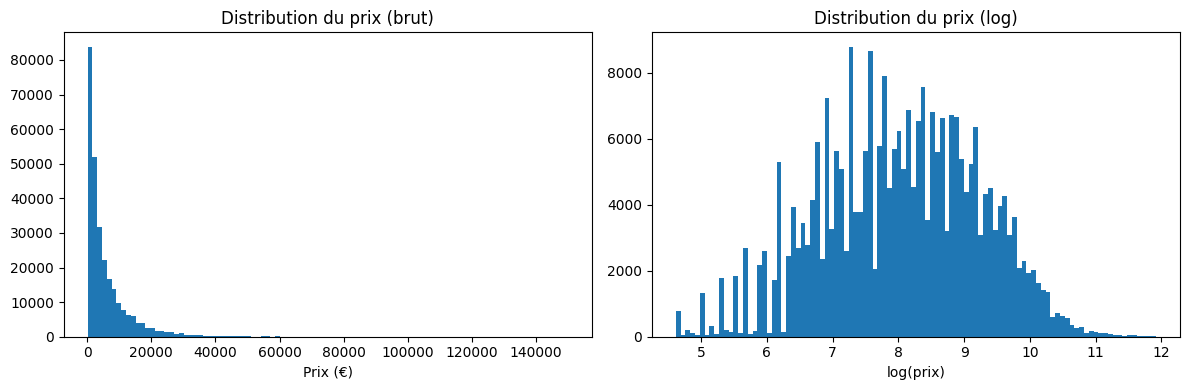

In [ ]:
import matplotlib.pyplot as plt
# Je compare la distribution du prix brut (gauche) et après log (droite)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=100)
axes[0].set_title("Distribution du prix (brut)")
axes[0].set_xlabel("Prix (€)")
axes[1].hist(np.log1p(y_train), bins=100)
axes[1].set_title("Distribution du prix (log)")
axes[1].set_xlabel("log(prix)")
plt.tight_layout()
plt.savefig('graphe_distribution_prix.png', dpi=150, bbox_inches='tight')
plt.show()

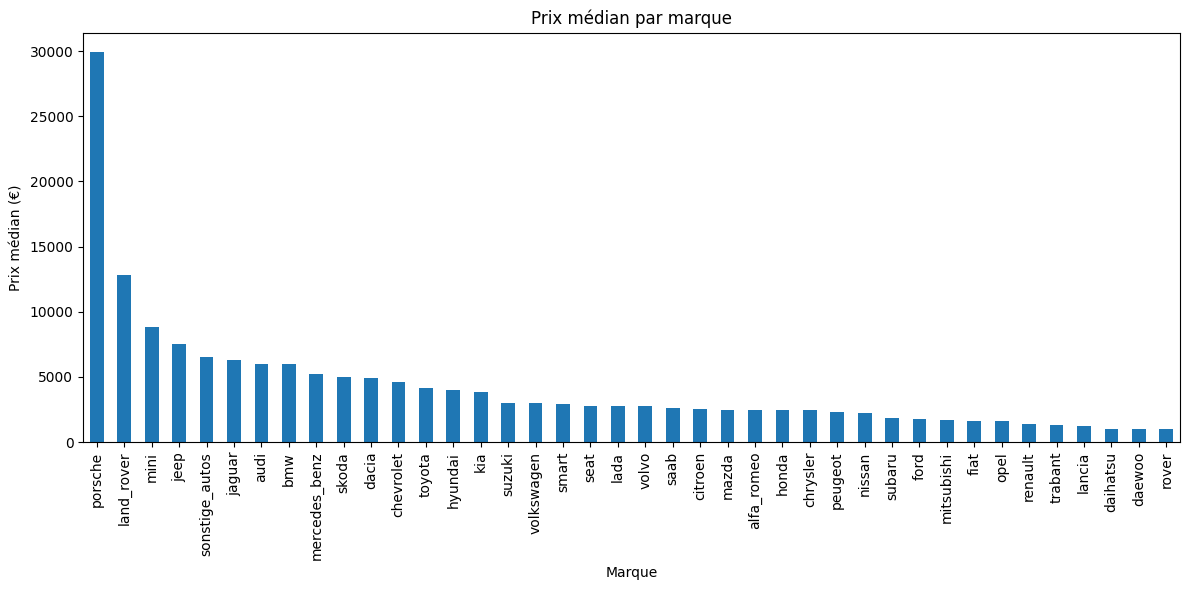

In [ ]:
# Graphe : prix médian par marque
prix_marque = data.groupby('brand')['price'].median().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
prix_marque.plot(kind='bar')
plt.title("Prix médian par marque")
plt.ylabel("Prix médian (€)")
plt.xlabel("Marque")
plt.tight_layout()
plt.savefig('graphe_prix_marque.png', dpi=150, bbox_inches='tight')
plt.show()

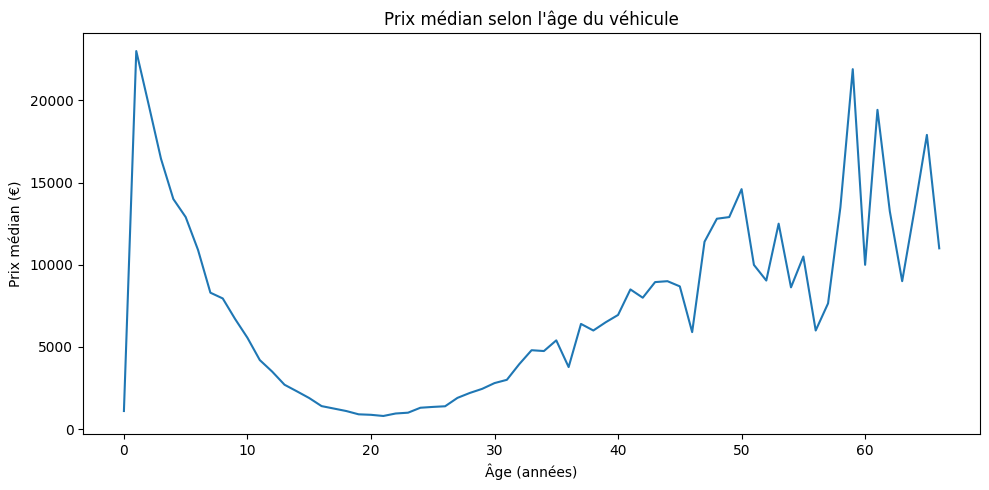

In [31]:
# Graphe : prix médian selon l'âge du véhicule
prix_age = data.groupby('age')['price'].median()
plt.figure(figsize=(10, 5))
prix_age.plot()
plt.title("Prix médian selon l'âge du véhicule")
plt.xlabel("Âge (années)")
plt.ylabel("Prix médian (€)")
plt.tight_layout()
plt.savefig('graphe_prix_age.png', dpi=150, bbox_inches='tight')
plt.show()

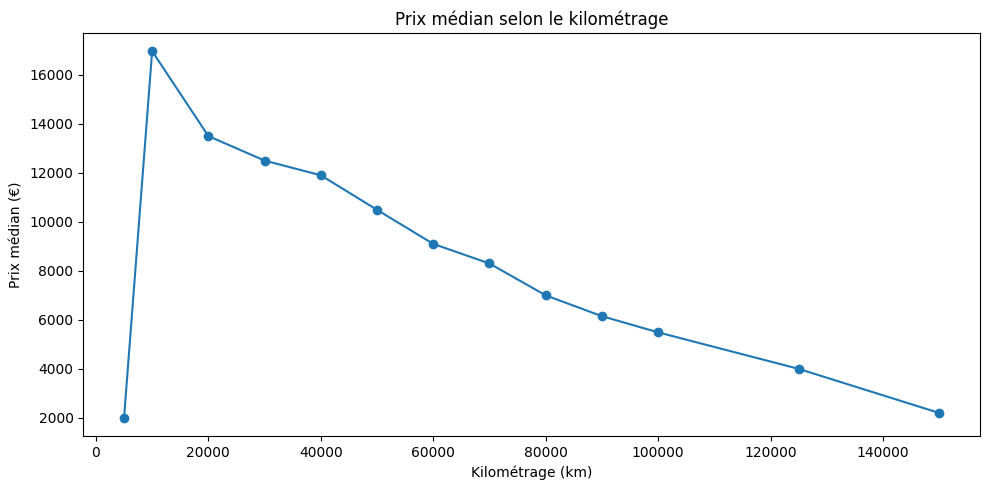

In [32]:
# Graphe : prix médian selon le kilométrage
prix_km = data.groupby('kilometer')['price'].median()
plt.figure(figsize=(10, 5))
prix_km.plot(marker='o')
plt.title("Prix médian selon le kilométrage")
plt.xlabel("Kilométrage (km)")
plt.ylabel("Prix médian (€)")
plt.tight_layout()
plt.savefig('graphe_prix_km.png', dpi=150, bbox_inches='tight')
plt.show()

le prix chute fortement avec l'âge surtout les 10 premières années et aussi aprés les 20000 kms ; les marques premium (porsche, mercedes) ont les prix médians les plus élevés

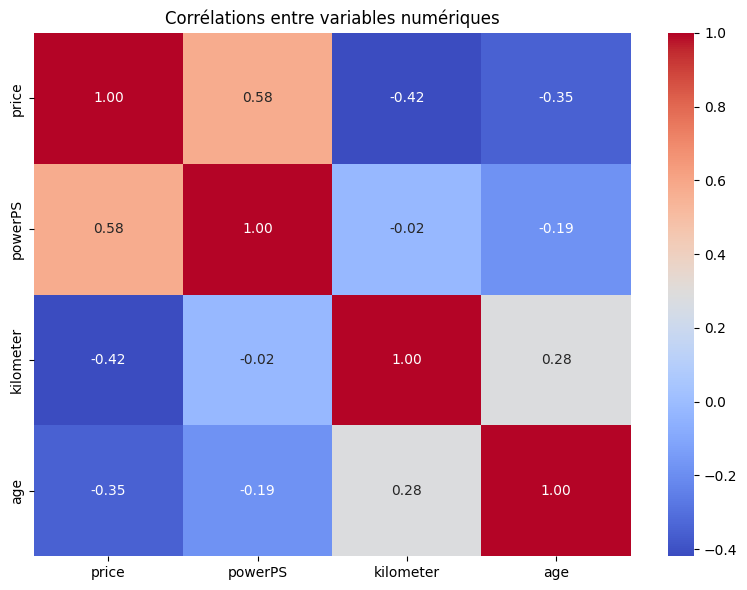

In [33]:
# Heatmap des corrélations entre variables numériques
num_cols = ['price', 'powerPS', 'kilometer', 'age']
plt.figure(figsize=(8, 6))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Corrélations entre variables numériques")
plt.tight_layout()
plt.savefig('graphe_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

La heatmap montre que le prix est surtout influencé par la puissance (corrélation positive +0.58 : plus la voiture est puissante, plus elle est chère). Le kilométrage (-0.42) et l'âge (-0.35) ont une corrélation négative : une voiture plus kilométrée ou plus vieille se vend moins cher. On note aussi que l'âge et le kilométrage sont liés (+0.28), ce qui est logique (les vieilles voitures ont roulé davantage).

Le prix brut est fortement asymétrique : la majorité des voitures sont bon marché et quelques-unes très chères. Après transformation log, la distribution devient quasi symétrique (en cloche). C'est pourquoi j'entraîne les modèles sur le log du prix, ce qui les aide à mieux apprendre

In [ ]:

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print("y_train_log -> min :", round(y_train_log.min(), 2),
      "| max :", round(y_train_log.max(), 2))

y_train_log -> min : 4.62 | max : 11.92


## 6. Modélisation

> On commencer par une régression linéaire comme modèle de référence (baseline) car c'est le modéle le plus simple ce qui sert de point de comparaison et puis on utilise des algorithmes plus complexes et on compare les pérformences (R², MAE, RMSE) à cette baseline


In [35]:
from sklearn.linear_model import LinearRegression

model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_lr.fit(X_train, y_train_log)

print("Modèle entraîné ✓")

Modèle entraîné ✓


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = model_lr.predict(X_test)

y_pred = np.expm1(y_pred_log)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.0f} €")
print(f"RMSE : {rmse:,.0f} €")
print(f"R²   : {r2:.3f}")

MAE  : 2,402 €
RMSE : 8,652 €
R²   : -0.161


Je vérifie pourquoi la régression linéaire a un R² négatif :
je regarde les prédictions extrêmes et je compte les valeurs absurdes.

In [ ]:

print("Prédiction max (€) :", f"{y_pred.max():,.0f}")
print("Prédiction min (€) :", f"{y_pred.min():,.0f}")
print("Vrai prix max (€)  :", f"{y_test.max():,.0f}")


print("\nPrédictions > 200 000 € :", (y_pred > 200000).sum())
print("Prédictions > 1 000 000 € :", (y_pred > 1000000).sum())

Prédiction max (€) : 801,298
Prédiction min (€) : 35
Vrai prix max (€)  : 144,997

Prédictions > 200 000 € : 49
Prédictions > 1 000 000 € : 0


 La régression linéaire extrapole trop loin (jusqu'à 800 000 €), ce qui fausse le score.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluer_modele(nom, modele, X_tr, y_tr_log, X_te, y_te, y_te_log):
    modele.fit(X_tr, y_tr_log)
    pred_log = modele.predict(X_te)
    pred_eur = np.expm1(pred_log)

    # Sécurité : on borne les prédictions au max réaliste observé
    pred_eur = np.clip(pred_eur, 0, 200000)

    return {
        'Modèle': nom,
        'R2_log': r2_score(y_te_log, pred_log),
        'RMSE_log': np.sqrt(mean_squared_error(y_te_log, pred_log)),
        'MAE_eur': mean_absolute_error(y_te, pred_eur),
        'R2_eur': r2_score(y_te, pred_eur)
    }

In [39]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

modeles = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'KNN': KNeighborsRegressor(n_neighbors=10),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

print(len(modeles), "modèles à tester")

11 modèles à tester


ON teste les 11 algorithmes automatiquement.
Pour chacun : on a un pipeline (préprocessing + modèle), entraînement, évaluation et mesure du temps. et enfin tous les résultats sont rassemblés dans un tableau pour comparer les performances d'un coup.

In [40]:
# [À COMPLÉTER : explique que cette boucle teste les 11 algorithmes d'un coup et compare leurs scores]
import time

resultats = []

for nom, modele in modeles.items():
    t0 = time.time()

    # Pipeline complet : préprocessing + modèle
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', modele)
    ])

    # Évaluation
    res = evaluer_modele(nom, pipe, X_train, y_train_log, X_test, y_test, y_test_log)
    res['Temps_s'] = round(time.time() - t0, 1)

    resultats.append(res)
    print(f"✓ {nom:20s} | R2_log={res['R2_log']:.3f} | MAE={res['MAE_eur']:,.0f}€ | {res['Temps_s']}s")

print("\nTerminé !")

✓ LinearRegression     | R2_log=0.705 | MAE=2,332€ | 4.8s
✓ Ridge                | R2_log=0.705 | MAE=2,331€ | 3.9s
✓ Lasso                | R2_log=-0.000 | MAE=4,534€ | 1.6s
✓ ElasticNet           | R2_log=0.096 | MAE=4,376€ | 2.1s
✓ KNN                  | R2_log=0.830 | MAE=1,410€ | 517.1s
✓ DecisionTree         | R2_log=0.793 | MAE=1,402€ | 107.0s
✓ RandomForest         | R2_log=0.849 | MAE=1,225€ | 1102.6s
✓ ExtraTrees           | R2_log=0.841 | MAE=1,227€ | 1275.3s
✓ GradientBoosting     | R2_log=0.814 | MAE=1,640€ | 33.7s
✓ XGBoost              | R2_log=0.850 | MAE=1,382€ | 3.2s
✓ LightGBM             | R2_log=0.842 | MAE=1,452€ | 3.1s

Terminé !


c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [41]:
df_resultats = pd.DataFrame(resultats).sort_values('R2_log', ascending=False).reset_index(drop=True)
df_resultats

,Modèle,R2_log,RMSE_log,MAE_eur,R2_eur,Temps_s
0,XGBoost,0.850029,0.469061,1382.236328,0.827617,3.2
1,RandomForest,0.849381,0.470072,1225.280274,0.848474,1102.6
2,LightGBM,0.842329,0.480951,1451.637019,0.802541,3.1
3,ExtraTrees,0.841237,0.482614,1226.889738,0.844031,1275.3
4,KNN,0.830183,0.499132,1410.340969,0.820534,517.1
5,GradientBoosting,0.813580,0.522963,1640.240215,0.753011,33.7
6,DecisionTree,0.792590,0.551620,1401.678651,0.779815,107.0
7,LinearRegression,0.705108,0.657743,2332.433209,0.336716,4.8
8,Ridge,0.705093,0.657760,2330.989148,0.339562,3.9
9,ElasticNet,0.096202,1.151492,4375.941694,-0.077908,2.1


## 7. Tuning et choix du modèle final

> Apres tester les 11 modéles , les mieux classés (R²_log): XGBoost,RandomForest,LightGBM , (on a aussi une divérsité entre le bagging et le boosting) , donc on fait un tunning on changeant les hyperparametres deja fixées en random et de cross-validation pour enfin choisir un modéle final en se basant sur la performance et l'overfitting 


In [42]:
from sklearn.model_selection import RandomizedSearchCV

# Pipeline XGBoost
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, n_jobs=-1))
])

# Grille d'hyperparamètres (le préfixe 'regressor__' cible le modèle dans le pipeline)
params_xgb = {
    'regressor__n_estimators': [200, 400, 600],
    'regressor__max_depth': [4, 6, 8, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.7, 0.8, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0]
}

search_xgb = RandomizedSearchCV(
    pipe_xgb, params_xgb,
    n_iter=20,                 # 20 combinaisons testées
    cv=3,                      # validation croisée 3 folds
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_xgb.fit(X_train, y_train_log)

print("Meilleurs paramètres :", search_xgb.best_params_)
print("Meilleur R2_log (CV) :", round(search_xgb.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'regressor__subsample': 1.0, 'regressor__n_estimators': 600, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.8}
Meilleur R2_log (CV) : 0.8625


In [43]:
# Pipeline LightGBM
pipe_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

params_lgbm = {
    'regressor__n_estimators': [200, 400, 600],
    'regressor__max_depth': [6, 8, 10, -1],     # -1 = pas de limite
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [31, 63, 127],     # paramètre clé de LightGBM
    'regressor__subsample': [0.7, 0.8, 1.0]
}

search_lgbm = RandomizedSearchCV(
    pipe_lgbm, params_lgbm,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_lgbm.fit(X_train, y_train_log)

print("Meilleurs paramètres :", search_lgbm.best_params_)
print("Meilleur R2_log (CV) :", round(search_lgbm.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'regressor__subsample': 1.0, 'regressor__num_leaves': 127, 'regressor__n_estimators': 600, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.1}
Meilleur R2_log (CV) : 0.8627


In [ ]:
# Échantillon pour accélérer la recherche RF
X_train_sample = X_train.sample(n=60000, random_state=42)
y_train_log_sample = y_train_log.loc[X_train_sample.index]

# Pipeline RandomForest
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

params_rf = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [15, 25, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__max_features': ['sqrt', 0.5]
}

search_rf = RandomizedSearchCV(
    pipe_rf, params_rf,
    n_iter=6,                  
    cv=2,                      
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Recherche sur l'échantillon
search_rf.fit(X_train_sample, y_train_log_sample)

print("Meilleurs paramètres :", search_rf.best_params_)
print("Meilleur R2_log (CV, échantillon) :", round(search_rf.best_score_, 4))

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Meilleurs paramètres : {'regressor__n_estimators': 100, 'regressor__min_samples_split': 5, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None}
Meilleur R2_log (CV, échantillon) : 0.8266


In [ ]:
# RandomForest final avec les meilleurs params, sur TOUTES les données
rf_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100, min_samples_split=5,
        max_features='sqrt', max_depth=None,
        random_state=42, n_jobs=-1))
])
rf_final.fit(X_train, y_train_log)   
print("RF final entraîné ✓")

RF final entraîné ✓


In [46]:
# Les meilleurs modèles tunés sont accessibles via .best_estimator_
xgb_final = search_xgb.best_estimator_
lgbm_final = search_lgbm.best_estimator_
print("Boosters récupérés ✓")

Boosters récupérés ✓


In [ ]:
# On compare le score sur TRAIN et sur TEST pour détecter l'overfitting 
def evaluer_complet(nom, modele):
    # Prédictions train et test (échelle log)
    pred_train_log = modele.predict(X_train)
    pred_test_log  = modele.predict(X_test)

    # Reconversion en euros (avec borne de sécurité)
    pred_test_eur = np.clip(np.expm1(pred_test_log), 0, 200000)

    return {
        'Modèle': nom,
        'R2_log_train': r2_score(y_train_log, pred_train_log),
        'R2_log_test': r2_score(y_test_log, pred_test_log),
        'MAE_eur': mean_absolute_error(y_test, pred_test_eur),
        'RMSE_eur': np.sqrt(mean_squared_error(y_test, pred_test_eur)),
        'R2_eur_test': r2_score(y_test, pred_test_eur)
    }

comparatif = pd.DataFrame([
    evaluer_complet('XGBoost (tuné)', xgb_final),
    evaluer_complet('LightGBM (tuné)', lgbm_final),
    evaluer_complet('RandomForest (tuné)', rf_final)
])

comparatif

c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modèle,R2_log_train,R2_log_test,MAE_eur,RMSE_eur,R2_eur_test
0,XGBoost (tuné),0.890371,0.861730,1252.654907,3102.101546,0.850805
1,LightGBM (tuné),0.882963,0.861304,1248.948118,3070.154088,0.853862
2,RandomForest (tuné),0.924179,0.853277,1268.455997,3316.249489,0.829495


Résultat: On choisi LightGBM pour ces meilleures métriques de test et plus faible overfitting (écart train/test de 0.022, contre 0.071 pour RandomForest qui surapprend).

## 8. Sérialisation et déploiement

On sauvegarde le PIPELINE COMPLET (préprocessing + modèle) pour que le préprocessing se dait automatiquement et aussi pour que l'application Streamlit recoit que Rawdata et le pipeline fait tout l'imputation + normalisation + encodage + prédiction.


In [ ]:
import joblib

# lgbm_final est déjà entraîné
joblib.dump(lgbm_final, 'model_pipeline.joblib')

print("Pipeline sauvegardé ✓")

Pipeline sauvegardé ✓


In [49]:
# Recharger le pipeline
pipeline_charge = joblib.load('model_pipeline.joblib')

# Tester sur une vraie ligne du test
exemple = X_test.iloc[[0]]   # une voiture
print("Caractéristiques :")
print(exemple.T)             # .T pour afficher en colonne, plus lisible

# Prédiction (en log) puis reconversion en euros
pred_log = pipeline_charge.predict(exemple)
pred_eur = np.expm1(pred_log)[0]

print(f"\nPrix prédit : {pred_eur:,.0f} €")
print(f"Prix réel   : {y_test.iloc[0]:,.0f} €")

Caractéristiques :
                       323917
vehicleType         limousine
gearbox               manuell
powerPS                  75.0
model                    bora
kilometer              150000
fuelType               benzin
brand              volkswagen
notRepairedDamage        nein
age                        16

Prix prédit : 1,688 €
Prix réel   : 2,500 €


c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [50]:
# Valeurs uniques des colonnes catégorielles (pour les menus déroulants)
cat_options = {}
for col in ['vehicleType', 'gearbox', 'fuelType', 'brand', 'notRepairedDamage']:
    valeurs = sorted(X_train[col].dropna().unique().tolist())
    cat_options[col] = valeurs
    print(f"{col} ({len(valeurs)}) : {valeurs}\n")

print("Nombre de modèles :", X_train['model'].nunique())

for col in ['powerPS', 'kilometer', 'age']:
    print(f"{col} : min={X_train[col].min():.0f}, max={X_train[col].max():.0f}, médiane={X_train[col].median():.0f}")

vehicleType (8) : ['andere', 'bus', 'cabrio', 'coupe', 'kleinwagen', 'kombi', 'limousine', 'suv']

gearbox (2) : ['automatik', 'manuell']

fuelType (7) : ['andere', 'benzin', 'cng', 'diesel', 'elektro', 'hybrid', 'lpg']

brand (40) : ['alfa_romeo', 'audi', 'bmw', 'chevrolet', 'chrysler', 'citroen', 'dacia', 'daewoo', 'daihatsu', 'fiat', 'ford', 'honda', 'hyundai', 'jaguar', 'jeep', 'kia', 'lada', 'lancia', 'land_rover', 'mazda', 'mercedes_benz', 'mini', 'mitsubishi', 'nissan', 'opel', 'peugeot', 'porsche', 'renault', 'rover', 'saab', 'seat', 'skoda', 'smart', 'sonstige_autos', 'subaru', 'suzuki', 'toyota', 'trabant', 'volkswagen', 'volvo']

notRepairedDamage (2) : ['ja', 'nein']

Nombre de modèles : 249
powerPS : min=1, max=1000, médiane=116
kilometer : min=5000, max=150000, médiane=150000
age : min=0, max=66, médiane=13


On utilise 2 modéles (10% et 90%) pour encadrer la prédiction par un intervalle.
la régression ne donne pas de probabilité, l'intervalle joue le rôle de "niveau de confiance". 
L'app Streamlit donc va afficher ainsi fourchette de prix (~80% des cas) au lieu d'un seul chiffre.

In [ ]:

# Modèle borne basse (quantile 10%)
pipe_lower = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(objective='quantile', alpha=0.1,
                                 n_estimators=600, num_leaves=127,
                                 learning_rate=0.1, random_state=42,
                                 n_jobs=-1, verbose=-1))
])

# Modèle borne haute (quantile 90%)
pipe_upper = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(objective='quantile', alpha=0.9,
                                 n_estimators=600, num_leaves=127,
                                 learning_rate=0.1, random_state=42,
                                 n_jobs=-1, verbose=-1))
])

# Entraînement sur la cible log (rapide, ~quelques secondes chacun)
pipe_lower.fit(X_train, y_train_log)
pipe_upper.fit(X_train, y_train_log)
print("Modèles quantile entraînés ✓")

Modèles quantile entraînés ✓


In [52]:
ex = X_test.iloc[[0]]
centre = np.expm1(lgbm_final.predict(ex))[0]
bas    = np.expm1(pipe_lower.predict(ex))[0]
haut   = np.expm1(pipe_upper.predict(ex))[0]
print(f"Intervalle : {bas:,.0f} € — {centre:,.0f} € — {haut:,.0f} €")
print(f"Prix réel  : {y_test.iloc[0]:,.0f} €")

Intervalle : 1,233 € — 1,688 € — 2,516 €
Prix réel  : 2,500 €


c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\EEMohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [53]:
joblib.dump({
    'model': lgbm_final,
    'lower': pipe_lower,
    'upper': pipe_upper
}, 'model_pipeline.joblib')
print("Pipeline complet (centre + intervalle) sauvegardé ✓")

Pipeline complet (centre + intervalle) sauvegardé ✓


In [54]:
# Dictionnaire {marque: [modèles de cette marque]}
brand_models = (
    X_train.dropna(subset=['model'])
    .groupby('brand')['model']
    .apply(lambda s: sorted(s.unique().tolist()))
    .to_dict()
)

print("Modèles Volkswagen :", brand_models['volkswagen'])

# Sauvegarde des options pour l'app
joblib.dump({'cat_options': cat_options, 'brand_models': brand_models}, 'app_options.joblib')
print("Options sauvegardées ✓")

Modèles Volkswagen : ['amarok', 'andere', 'beetle', 'bora', 'caddy', 'cc', 'eos', 'fox', 'golf', 'jetta', 'kaefer', 'lupo', 'passat', 'phaeton', 'polo', 'scirocco', 'sharan', 'tiguan', 'touareg', 'touran', 'transporter', 'up']
Options sauvegardées ✓
